# 3. Decay domain

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import os
import time
import cooler
from glob import glob
from concurrent.futures import ProcessPoolExecutor, as_completed

import qnorm
import anndata
from scipy.stats import zscore

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [2]:
indir = f'{ENTEX_ROOT}/'


In [3]:
L1meta = pd.read_csv(f'{ENTEX_ROOT}/L1color.tsv', sep='\t', header=0, index_col=0)
L1meta['L1_annot'] = L1meta['L1_annot'].str.replace(' ','-').str.replace('/','_')


In [5]:
res = 25000
chrom_size_path = '/large_experiments/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [13]:
mode = 'raw'
adata = anndata.read_h5ad(f'domain/L1_{mode}.boundary.h5ad')
adata = adata[:, adata.var['chrom'].isin(chrom_sizes.index)]
adata

View of AnnData object with n_obs × n_vars = 35 × 115009
    var: 'chrom', 'start', 'end'

In [14]:
bin_tmp = adata.var.copy()
bin_tmp.index = bin_tmp.index.astype(int)
chrom_offset = {c: bin_tmp[bin_tmp['chrom'] == c].index[0] for c in chrom_sizes.index}


In [70]:
domain_size = []
for i,ct in enumerate(adata.obs.index):
    tmp = adata.X[i]
    tmp = np.diff(np.repeat(tmp.indices, tmp.data))[0::2]
    tmp = pd.DataFrame(tmp[:, None], columns=['size'])
    tmp['L1'] = ct
    domain_size.append(tmp)

domain_size = pd.concat(domain_size, axis=0).reindex()

In [75]:
domain_size['size'] = domain_size['size'] * res

[Text(0, 0, 'Endo-Lym'),
 Text(1, 0, 'Endo-Ves'),
 Text(2, 0, 'Epi-Aci'),
 Text(3, 0, 'Epi-AdrCtx'),
 Text(4, 0, 'Epi-Alv'),
 Text(5, 0, 'Epi-BrstBasal'),
 Text(6, 0, 'Epi-Duc'),
 Text(7, 0, 'Epi-Endcri'),
 Text(8, 0, 'Epi-Ent'),
 Text(9, 0, 'Epi-Gas'),
 Text(10, 0, 'Epi-Krt_Lum'),
 Text(11, 0, 'Epi-TPB'),
 Text(12, 0, 'Fibro-Adr'),
 Text(13, 0, 'Fibro-Brst'),
 Text(14, 0, 'Fibro-EndN'),
 Text(15, 0, 'Fibro-EpiN'),
 Text(16, 0, 'Fibro-GI'),
 Text(17, 0, 'Fibro-HT'),
 Text(18, 0, 'Fibro-Mus'),
 Text(19, 0, 'Fibro-Myo'),
 Text(20, 0, 'Fibro-Sk'),
 Text(21, 0, 'Glia-Astro'),
 Text(22, 0, 'Glia-Oligo'),
 Text(23, 0, 'Hema-B'),
 Text(24, 0, 'Hema-Mast'),
 Text(25, 0, 'Hema-Myeloid'),
 Text(26, 0, 'Hema-NK'),
 Text(27, 0, 'Hema-Tmem'),
 Text(28, 0, 'Hema-Tnaive'),
 Text(29, 0, 'Mus-Crd'),
 Text(30, 0, 'Mus-Skl'),
 Text(31, 0, 'Neu-Exc'),
 Text(32, 0, 'Neu-Inh'),
 Text(33, 0, 'Neu-Schw'),
 Text(34, 0, 'SmMus_Peri')]

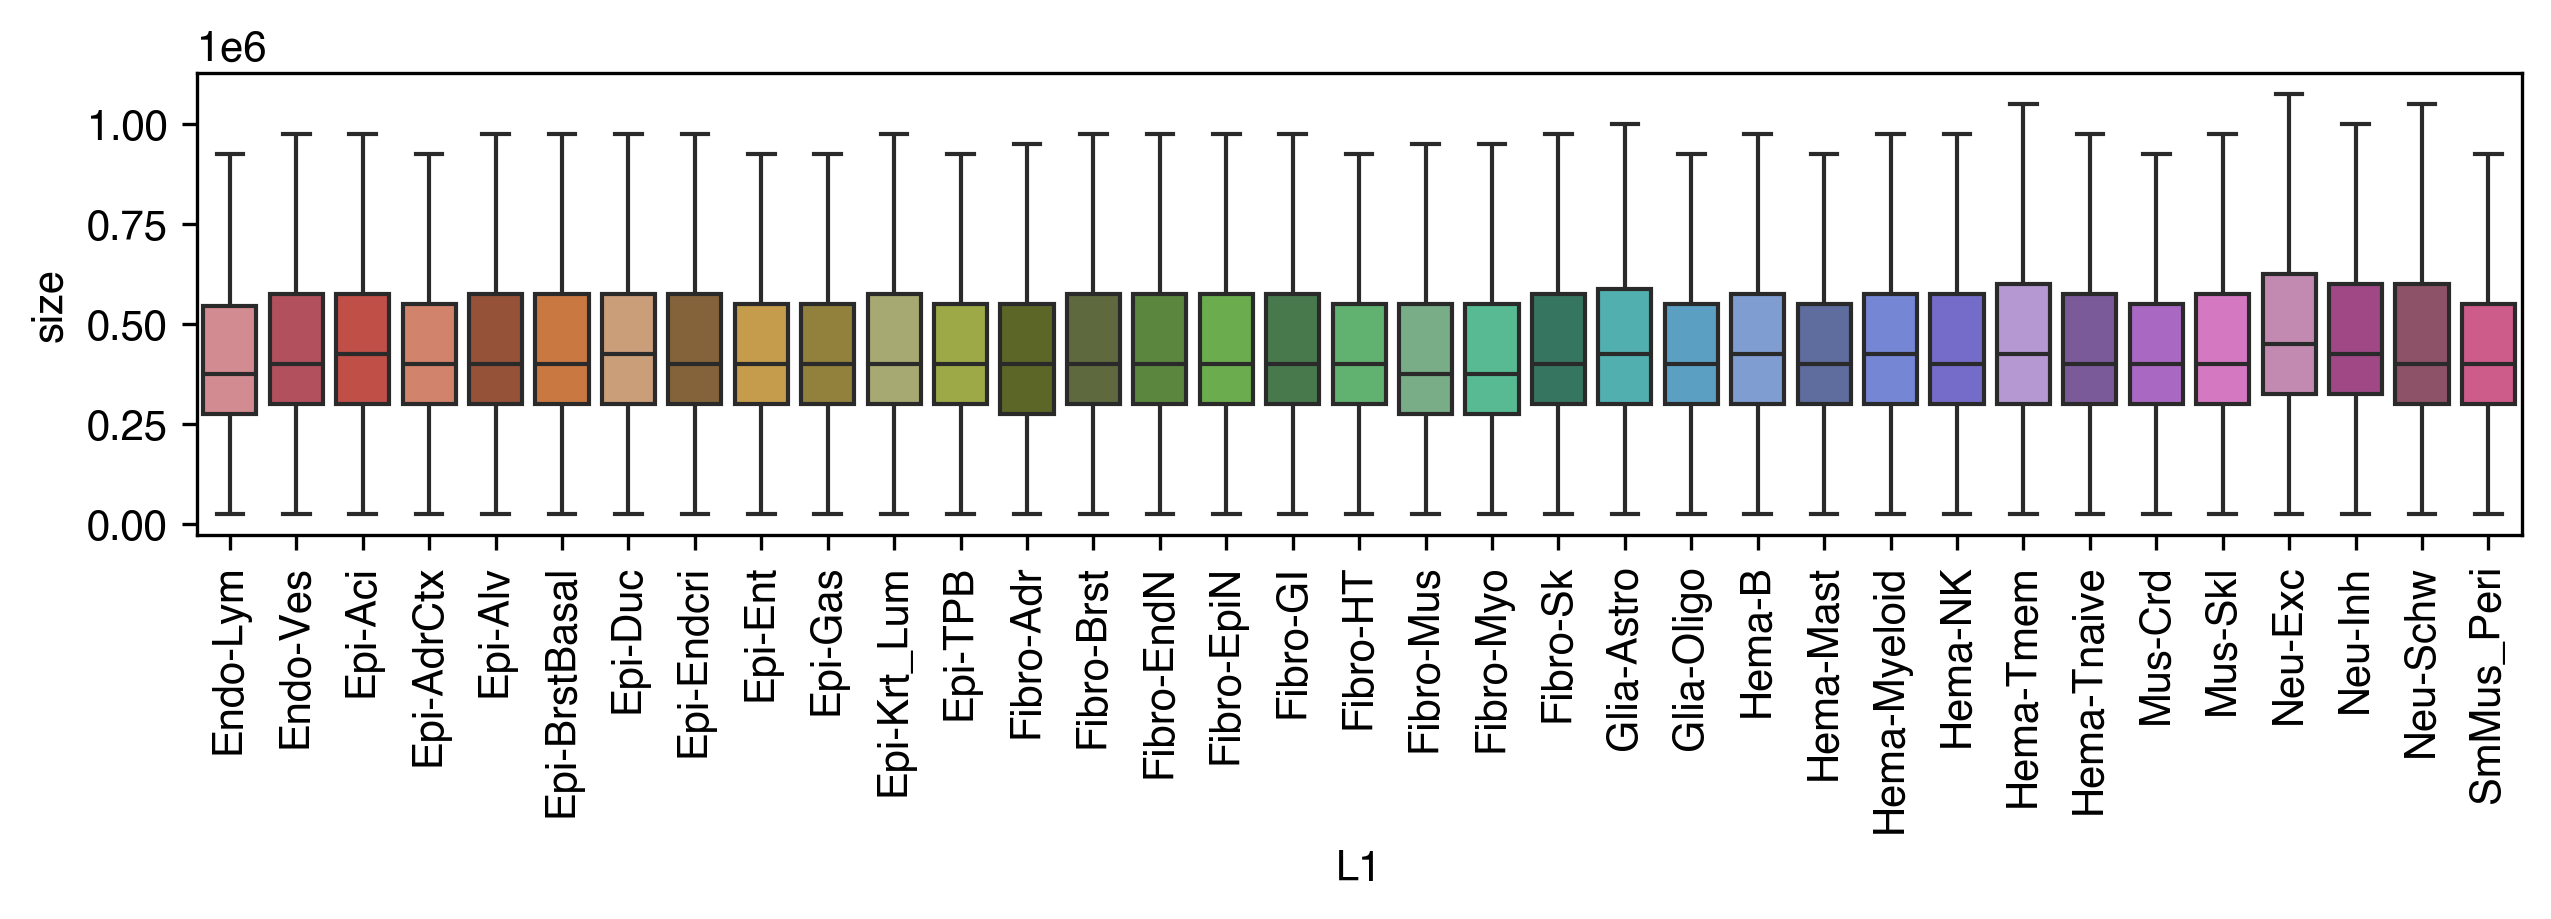

In [83]:
fig, ax = plt.subplots(figsize=(10, 2), dpi=300)
sns.boxplot(data=domain_size, x='L1', y='size', order=L1meta.index, 
               showfliers=False, 
               palette=L1meta['color'].to_dict(), ax=ax)
ax.set_xticklabels(L1meta['L1_annot'], rotation=90)

In [20]:
ws = 10
domain = {}
for i,ct in enumerate(adata.obs.index):
    domaintmp = adata.X.indices[adata.X.indptr[i]:adata.X.indptr[i+1]]
    domainfilter = (bin_tmp.loc[domaintmp, 'start'] >= (ws * res)) & (bin_tmp.loc[domaintmp, 'start'] < (bin_tmp.loc[domaintmp, 'chrom'].map(chrom_sizes).astype(int) - ws * res))
    domain[ct] = domaintmp[domainfilter]
    

In [22]:
meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs
leg = meta.groupby('L1')['Short/Long'].median().sort_values().index[::-1]


In [47]:
def contact_hist(ct):
    count = np.zeros((ws*2, ws*2))
    cool = cooler.Cooler(f'{indir}merged_cool_raw/L1/{ct}.mcool::resolutions/25000')
    for i,c in enumerate(chrom_sizes.index):
        data = cool.matrix(balance=False, sparse=True).fetch(c).tocsr()
        domaintmp = domain[ct][bin_tmp.loc[domain[ct], 'chrom']==c] - chrom_offset[c]
        for xx in domaintmp:
            count += data[(xx-ws):(xx+ws), (xx-ws):(xx+ws)].toarray()
    return count
    

In [48]:
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in L1meta.index:
        future = executor.submit(
            contact_hist,
            ct=ct,
        )
        futures[future] = ct
    count = {}
    for future in as_completed(futures):
        ct = futures[future]
        count[ct] = future.result()
        print(f'{ct} finished')


c34 finished
c32 finished
c30 finished
c33 finished
c29 finished
c31 finished
c26 finished
c27 finished
c22 finished
c25 finished
c28 finished
c24 finished
c20 finished
c23 finished
c15 finished
c13 finished
c18 finished
c11 finished
c14 finished
c19 finished
c17 finished
c9 finished
c16 finished
c10 finished
c21 finished
c5 finished
c12 finished
c2 finished
c8 finished
c7 finished
c6 finished
c3 finished
c4 finished
c1 finished
c0 finished


In [49]:
ref = np.sum([count[ct] for ct in leg], axis=0)
# ref = ref / ref.sum()
ref = ref / meta['CisLongContact'].sum()

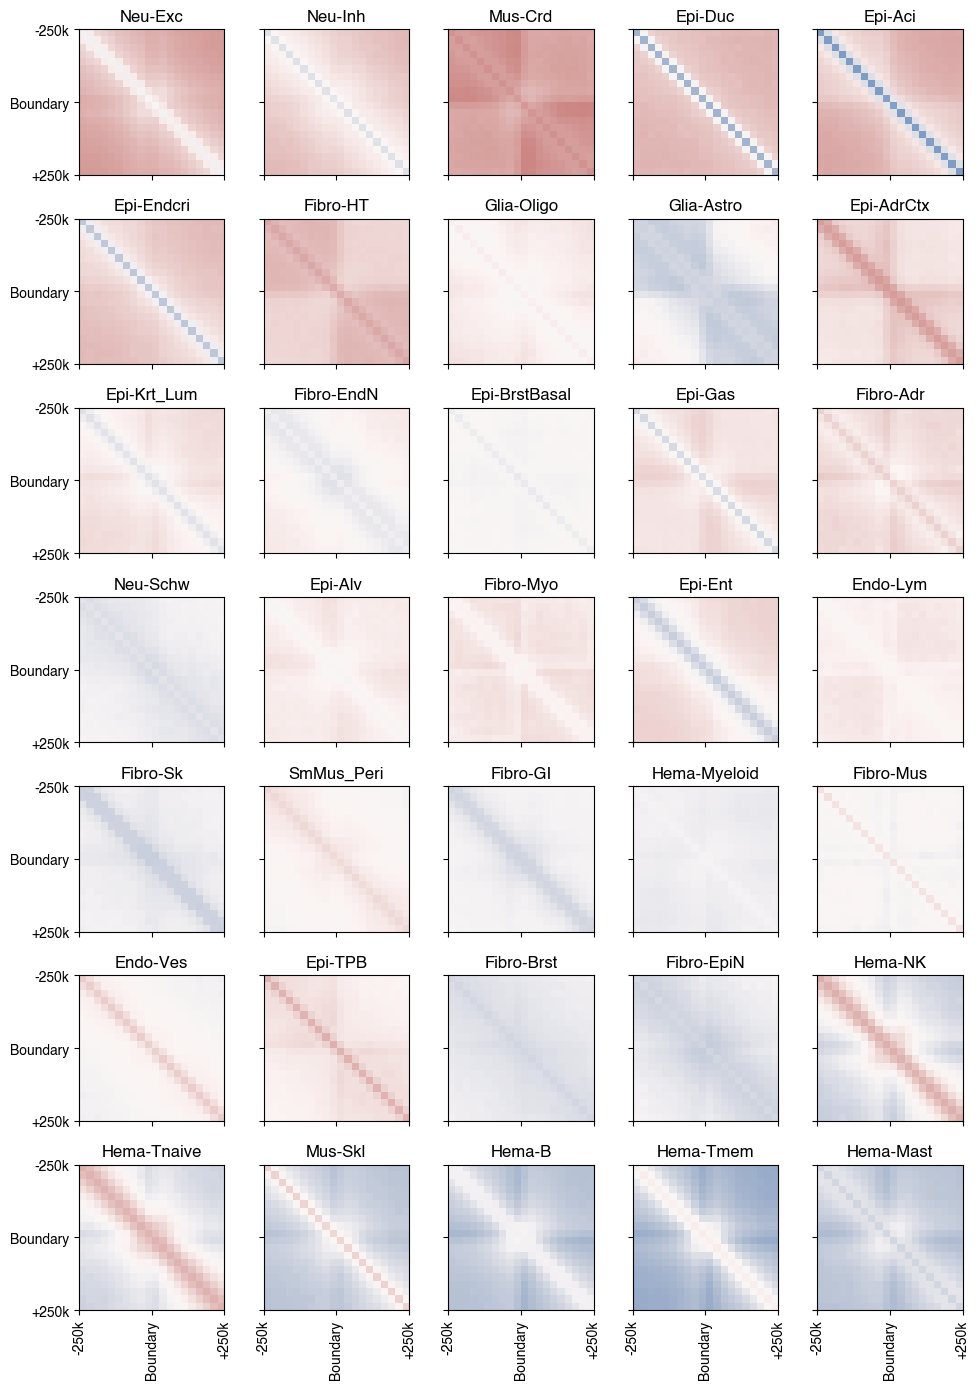

In [50]:
ticks = [-0.5, 9.5, 19.5]
ticklabels = ['-250k', 'Boundary', '+250k']

fig, axes = plt.subplots(7, 5, figsize=(10, 14), sharex='all', sharey='all')
for i,ct in enumerate(leg):
    ax = axes.flatten()[i]
    tmp = count[ct].copy()
    # tmp = tmp / tmp.sum()
    tmp = tmp / meta.loc[meta['L1']==ct, 'CisLongContact'].sum()
    tmp = np.log2(tmp / ref)
    ax.imshow(tmp, cmap='vlag', interpolation='none', vmin=-1, vmax=1)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels, rotation=90)
    ax.set_title(L1meta.loc[ct, 'L1_annot'])
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels)

plt.tight_layout()

In [25]:
chrom1 = 1
chrom2 = 5
pos1 = 2
pos2 = 6
n_bins = adata.shape[1]

from scipy.sparse import csr_matrix
def contact_hist(contact_path, ct):
    count = np.zeros((ws*2, ws*2))
    data = pd.read_csv(contact_path, sep='\t', header=None, index_col=None)
    data = data.loc[(data[chrom1]==data[chrom2]) & data[chrom1].isin(chrom_sizes.index) & (np.abs(data[pos1] - data[pos2]) > 2500)]
    data[pos1] = (data[pos1] - 1) // res + data[chrom1].map(chrom_offset).astype(int)
    data[pos2] = (data[pos2] - 1) // res + data[chrom1].map(chrom_offset).astype(int)
    data = data.loc[np.abs(data[pos2] - data[pos1]) <= (ws*2)]
    data = data.groupby(by=[pos1, pos2])[chrom1].count().reset_index()
    data = csr_matrix((data[chrom1].astype(np.int32), (data[pos1], data[pos2])), (n_bins, n_bins))
    for xx in domain[ct]:
        count += data[(xx-ws):(xx+ws), (xx-ws):(xx+ws)].toarray()
    return count
   

In [30]:
cpu = 32
for ct in L1meta.index:
    count = np.zeros((ws*2, ws*2))
    with ProcessPoolExecutor(cpu) as executor:
        futures = {}
        for cell in meta.index[meta['L1']==ct]:
            future = executor.submit(
                contact_hist,
                contact_path=f'{indir}contact/{cell}.3C.contact.rmbkl.tsv.gz',
                ct=ct,
            )
            futures[future] = cell
        for future in as_completed(futures):
            cell = futures[future]
            xx = future.result()
            count += xx
            # print(f'{cell} finished')

    np.save(f'decay_domain/{ct}_histdomain_{mode}.npy', count)
    print(f'{ct} finished')


c33 finished
c3 finished
c22 finished
c9 finished
c20 finished
c25 finished
c30 finished
c13 finished
c8 finished
c4 finished
c18 finished
c2 finished
c29 finished
c17 finished
c19 finished
c28 finished
c6 finished
c11 finished
c32 finished
c34 finished
c23 finished
c31 finished
c14 finished
c7 finished
c24 finished
c0 finished
c27 finished
c1 finished
c15 finished
c26 finished
c5 finished
c10 finished
c16 finished
c21 finished
c12 finished


In [37]:
mode = 'raw'
count = []
for ct in leg:
    tmpcount = np.load(f'decay_domain/{ct}_histdomain_{mode}.npy')
    tmpcount = tmpcount + tmpcount.T
    count.append(tmpcount)
    

In [41]:
ref = np.sum(count, axis=0)
# ref = ref / ref.sum()
ref = ref / meta['CisLongContact'].sum()

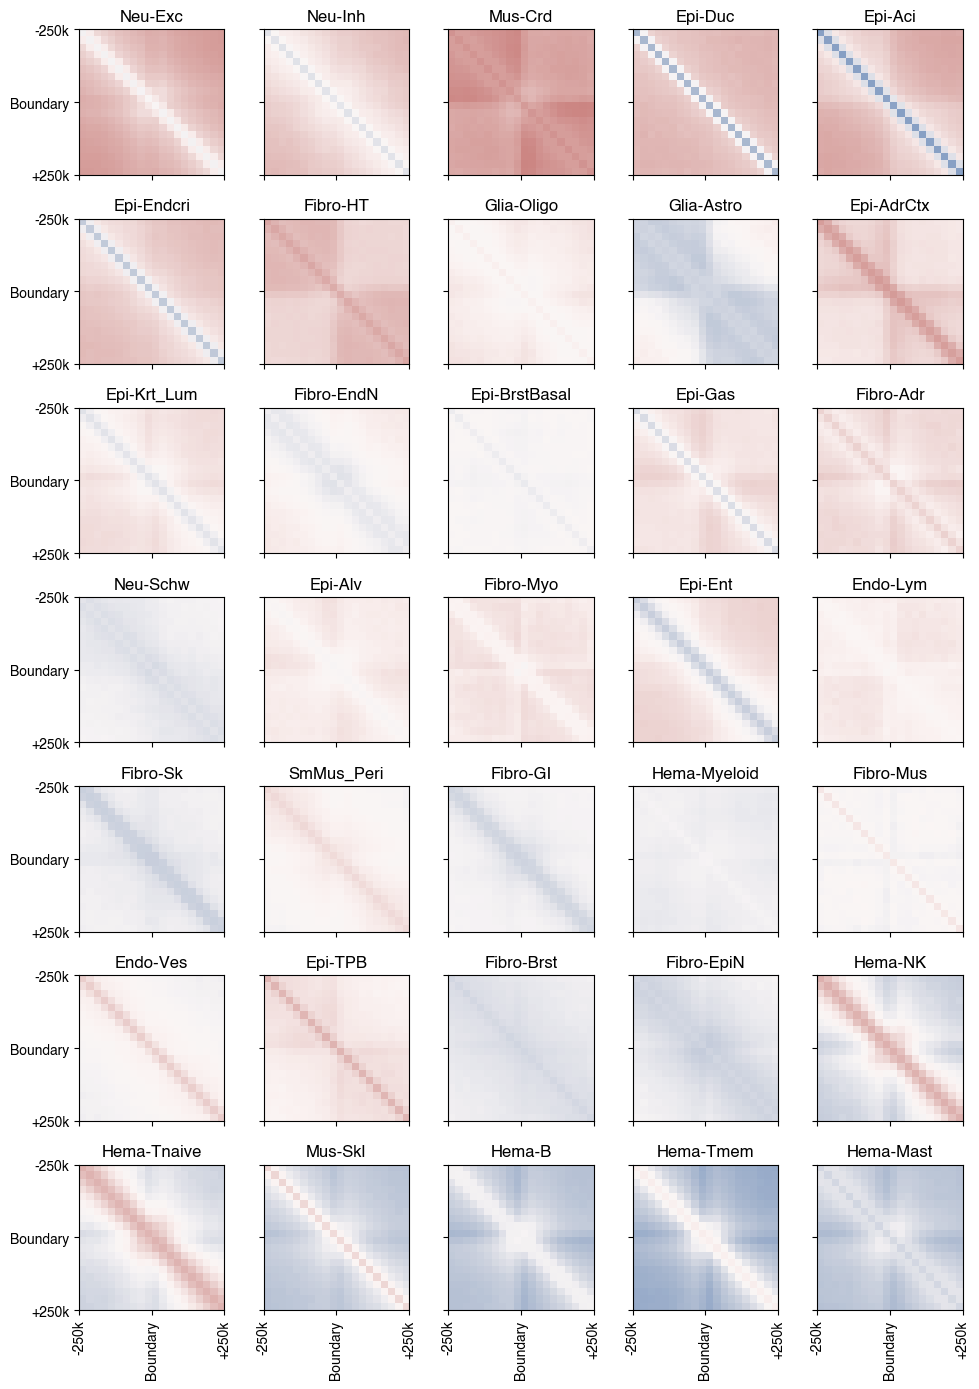

In [42]:
ticks = [-0.5, 9.5, 19.5]
ticklabels = ['-250k', 'Boundary', '+250k']

fig, axes = plt.subplots(7, 5, figsize=(10, 14), sharex='all', sharey='all')
for i,ct in enumerate(leg):
    ax = axes.flatten()[i]
    tmp = count[i].copy()
    # tmp = tmp / tmp.sum()
    tmp = tmp / meta.loc[meta['L1']==ct, 'CisLongContact'].sum()
    tmp = np.log2(tmp / ref)
    ax.imshow(tmp, cmap='vlag', interpolation='none', vmin=-1, vmax=1)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels, rotation=90)
    ax.set_title(L1meta.loc[ct, 'L1_annot'])
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels)

plt.tight_layout()